In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Model Selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Base Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

# Ensemble Classifiers
from sklearn.ensemble import (
    VotingClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier
)

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load dataset
df = pd.read_csv('diabetes_prediction_dataset.csv')
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [3]:
# Check information and missing values
df.info()
print("\nMissing values count:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB

Missing values count:
 gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


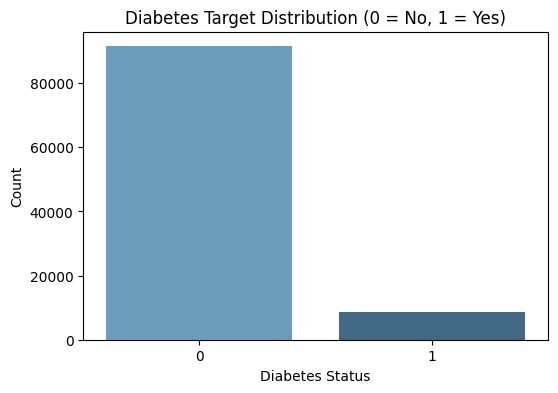

In [4]:
# Target distribution plot
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='diabetes', hue='diabetes', palette='Blues_d', legend=False)
plt.title('Diabetes Target Distribution (0 = No, 1 = Yes)')
plt.xlabel('Diabetes Status')
plt.ylabel('Count')
plt.show()

## 2. Data Preprocessing & Train-Test Split

In [5]:
# Remove duplicate rows
df = df.drop_duplicates()

# One-hot encode categorical features (gender, smoking_history)
df = pd.get_dummies(df, drop_first=True)

# Separate features (X) and target (y)
X = df.drop('diabetes', axis=1)
y = df['diabetes']

# Split dataset into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features for distance/gradient based models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

Training samples: 76916, Test samples: 19230


## 3. Base Classifiers Implementation

In [6]:
# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9596463858554343

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98     17534
           1       0.87      0.64      0.74      1696

    accuracy                           0.96     19230
   macro avg       0.92      0.81      0.86     19230
weighted avg       0.96      0.96      0.96     19230



In [7]:
# 2. Decision Tree Classifier
dt = DecisionTreeClassifier(max_depth=6, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.971606864274571



Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98     17534
           1       1.00      0.68      0.81      1696

    accuracy                           0.97     19230
   macro avg       0.98      0.84      0.90     19230
weighted avg       0.97      0.97      0.97     19230



In [8]:
# 3. K-Nearest Neighbors (KNN)
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.9591783671346854

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.98     17534
           1       0.89      0.62      0.73      1696

    accuracy                           0.96     19230
   macro avg       0.92      0.80      0.85     19230
weighted avg       0.96      0.96      0.96     19230



In [9]:
# 4. Support Vector Machine (Linear SVM)
svm = LinearSVC(random_state=42, max_iter=3000, dual='auto')
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

print("Linear SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

Linear SVM Accuracy: 0.9596983879355174



Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.98     17534
           1       0.89      0.62      0.73      1696

    accuracy                           0.96     19230
   macro avg       0.93      0.80      0.85     19230
weighted avg       0.96      0.96      0.96     19230



## 4. Ensemble Learning Methods Implementation

In [10]:
# 1. Voting Classifier (Hard Voting)
voting = VotingClassifier(
    estimators=[('lr', lr), ('dt', dt), ('knn', knn)],
    voting='hard',
    n_jobs=-1
)
voting.fit(X_train_scaled, y_train)
y_pred_voting = voting.predict(X_test_scaled)

print("Voting Classifier Accuracy:", accuracy_score(y_test, y_pred_voting))
print("\nClassification Report:\n", classification_report(y_test, y_pred_voting))

Voting Classifier Accuracy: 0.9672386895475819

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98     17534
           1       0.98      0.64      0.78      1696

    accuracy                           0.97     19230
   macro avg       0.97      0.82      0.88     19230
weighted avg       0.97      0.97      0.96     19230



In [11]:
# 2. Bagging Classifier
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=6),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)
bagging.fit(X_train, y_train)
y_pred_bagging = bagging.predict(X_test)

print("Bagging Classifier Accuracy:", accuracy_score(y_test, y_pred_bagging))
print("\nClassification Report:\n", classification_report(y_test, y_pred_bagging))

Bagging Classifier Accuracy: 0.971606864274571

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98     17534
           1       1.00      0.68      0.81      1696

    accuracy                           0.97     19230
   macro avg       0.98      0.84      0.90     19230
weighted avg       0.97      0.97      0.97     19230



In [12]:
# 3. AdaBoost Classifier
adaboost = AdaBoostClassifier(n_estimators=50, random_state=42)
adaboost.fit(X_train, y_train)
y_pred_adaboost = adaboost.predict(X_test)

print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_adaboost))
print("\nClassification Report:\n", classification_report(y_test, y_pred_adaboost))

AdaBoost Accuracy: 0.971606864274571

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98     17534
           1       1.00      0.68      0.81      1696

    accuracy                           0.97     19230
   macro avg       0.98      0.84      0.90     19230
weighted avg       0.97      0.97      0.97     19230



In [13]:
# 4. Gradient Boosting Classifier
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.9718148725949038

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98     17534
           1       0.99      0.69      0.81      1696

    accuracy                           0.97     19230
   macro avg       0.98      0.84      0.90     19230
weighted avg       0.97      0.97      0.97     19230



In [14]:
# 5. Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.971606864274571

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98     17534
           1       1.00      0.68      0.81      1696

    accuracy                           0.97     19230
   macro avg       0.98      0.84      0.90     19230
weighted avg       0.97      0.97      0.97     19230



## 5. Model Comparison & Visualizations

In [15]:
# Store predictions dictionary for simple comparison
all_preds = {
    'Logistic Regression': y_pred_lr,
    'Decision Tree': y_pred_dt,
    'KNN': y_pred_knn,
    'Linear SVM': y_pred_svm,
    'Voting Classifier': y_pred_voting,
    'Bagging Classifier': y_pred_bagging,
    'AdaBoost': y_pred_adaboost,
    'Gradient Boosting': y_pred_gb,
    'Random Forest': y_pred_rf
}

# Create summary metrics DataFrame
summary_list = []
for model_name, preds in all_preds.items():
    summary_list.append({
        'Model': model_name,
        'Accuracy': round(accuracy_score(y_test, preds), 4),
        'Precision': round(precision_score(y_test, preds), 4),
        'Recall': round(recall_score(y_test, preds), 4),
        'F1-Score': round(f1_score(y_test, preds), 4)
    })

comparison_df = pd.DataFrame(summary_list)
comparison_df = comparison_df.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
print(comparison_df)

                 Model  Accuracy  Precision  Recall  F1-Score
0    Gradient Boosting    0.9718     0.9865  0.6899    0.8119
1        Random Forest    0.9716     1.0000  0.6781    0.8082
2        Decision Tree    0.9716     1.0000  0.6781    0.8082
3   Bagging Classifier    0.9716     1.0000  0.6781    0.8082
4             AdaBoost    0.9716     1.0000  0.6781    0.8082
5    Voting Classifier    0.9672     0.9759  0.6445    0.7763
6  Logistic Regression    0.9596     0.8692  0.6386    0.7362
7           Linear SVM    0.9597     0.8939  0.6162    0.7295
8                  KNN    0.9592     0.8857  0.6167    0.7271


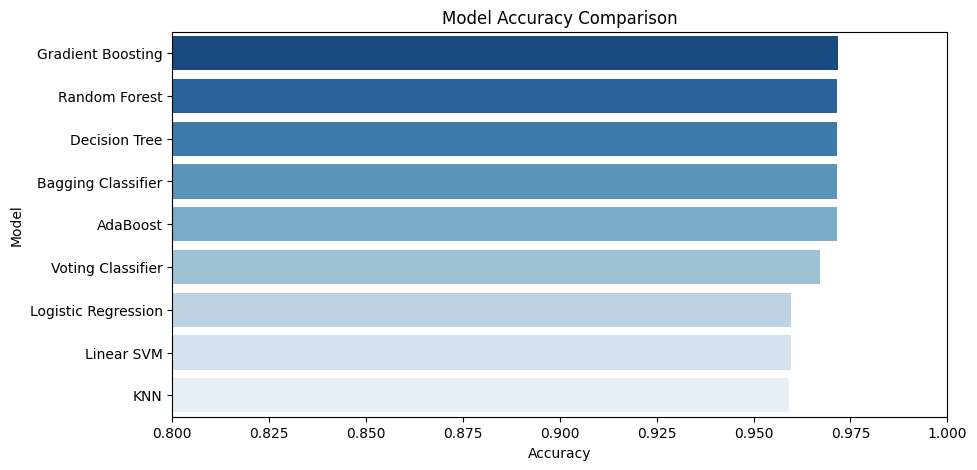

In [16]:
# 1. Model Accuracy Comparison Bar Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df, x='Accuracy', y='Model', hue='Model', palette='Blues_r', legend=False)
plt.title('Model Accuracy Comparison')
plt.xlabel('Accuracy')
plt.xlim(0.8, 1.0)
plt.show()

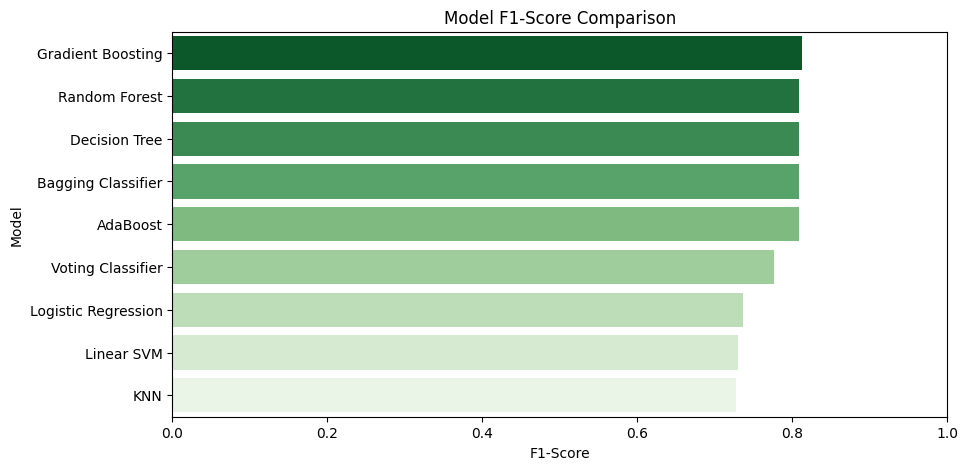

In [17]:
# 2. Model F1-Score Comparison Bar Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df, x='F1-Score', y='Model', hue='Model', palette='Greens_r', legend=False)
plt.title('Model F1-Score Comparison')
plt.xlabel('F1-Score')
plt.xlim(0, 1.0)
plt.show()

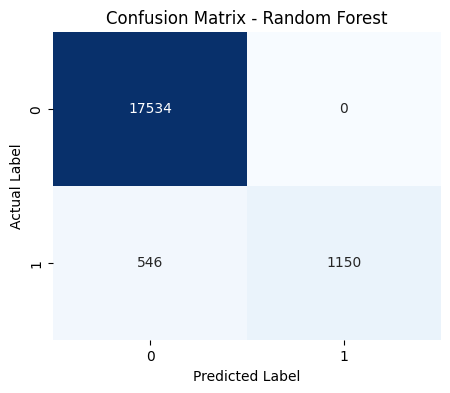

In [18]:
# 3. Confusion Matrix of Best Model (Random Forest)
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

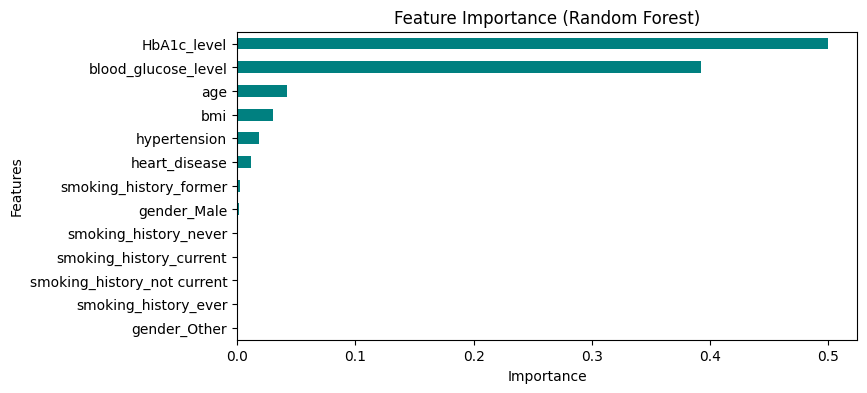

In [ ]:
        # 4. Feature Importance (Random Forest)
        plt.figure(figsize=(8, 4))
        feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
        feat_imp.plot(kind='barh', color='teal')
        plt.title('Feature Importance (Random Forest)')
        plt.xlabel('Importance')
        plt.ylabel('Features')
        plt.show()